# อ่านไฟล์ใน Assets แบบคร่าวๆ

In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
from IPython.display import display
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [83]:
dataframes = {}
for i in os.listdir('Assets'):
    print(f"อ่านไฟล์: {i}")
    dataframes[i] = pd.read_csv(os.path.join('Assets', i))
    display(dataframes[i].tail())
    print("-"*100)

อ่านไฟล์: stock_movement.csv


,stock_movement_id,datetime,store_id,product_id,qty
94,STK00095,2026-05-23 00:00:00,STR03,P008,5
95,STK00096,2026-05-25 00:00:00,STR03,P005,-2
96,STK00097,2026-05-25 00:00:00,STR03,P002,-2
97,STK00098,2026-05-19 00:00:00,STR01,P003,5
98,STK00099,2026-05-23 00:00:00,STR01,P012,-2


----------------------------------------------------------------------------------------------------
อ่านไฟล์: sales_transaction.csv


,sales_transaction_id,datetime,store_id,pos_id,product_id,qty
495,TX00496,2026-05-23 10:52:23,STR03,POS04,P015,1
496,TX00497,2026-05-24 17:22:07,STR03,POS02,P002,1
497,TX00498,2026-05-21 14:33:10,STR03,POS01,P009,2
498,TX00499,2026-05-26 07:57:28,STR02,POS01,P010,2
499,TX00500,2026-05-26 14:49:07,STR01,POS05,P009,1


----------------------------------------------------------------------------------------------------
อ่านไฟล์: purchasing_order.csv


,purchasing_order_id,warehouse_id,store_id,product_id,qty,arrival_date,expire_date
45,PO0046,WH01,STR03,P013,37,2026-05-22,2026-05-26
46,PO0047,WH01,STR01,P011,47,2026-05-20,2026-05-22
47,PO0048,WH01,STR03,P008,40,2026-05-21,2026-05-23
48,PO0049,WH01,STR01,P009,14,2026-05-19,2026-05-22
49,PO0050,WH01,STR01,P004,20,2026-05-21,2026-07-20


----------------------------------------------------------------------------------------------------
อ่านไฟล์: product_master.csv


,product_id,product_name,product_taxonomies
10,P011,Ham & Cheese Sandwich,Bakery
11,P012,Tuna Salad,Food
12,P013,Spaghetti Carbonara,Food
13,P014,Basil Pork Rice,Food
14,P015,Drinking Water,Beverage


----------------------------------------------------------------------------------------------------


# Merge ไฟล์ยอดขายกับชื่อสินค้า

In [84]:
sale_data = pd.merge(pd.read_csv('Assets/sales_transaction.csv', parse_dates=['datetime']),dataframes['product_master.csv'],on='product_id',how='inner')

sale_data.tail()

,sales_transaction_id,datetime,store_id,pos_id,product_id,qty,product_name,product_taxonomies
495,TX00496,2026-05-23 10:52:23,STR03,POS04,P015,1,Drinking Water,Beverage
496,TX00497,2026-05-24 17:22:07,STR03,POS02,P002,1,Americano,Beverage
497,TX00498,2026-05-21 14:33:10,STR03,POS01,P009,2,Orange Cake,Bakery
498,TX00499,2026-05-26 07:57:28,STR02,POS01,P010,2,Strawberry Shortcake,Bakery
499,TX00500,2026-05-26 14:49:07,STR01,POS05,P009,1,Orange Cake,Bakery


# EDA

## แบ่งช่วงเวลา

In [85]:
# Define time period function
def get_time_period(hour):
    if 7 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 15:
        return 'Afternoon'
    else:
        return 'Evening'

# Add hour and time_period
sale_data['hour'] = sale_data['datetime'].dt.hour
sale_data['time_period'] = sale_data['hour'].apply(get_time_period)

sale_data[['sales_transaction_id', 'product_name', 'product_taxonomies', 'qty', 'hour', 'time_period']].head()

,sales_transaction_id,product_name,product_taxonomies,qty,hour,time_period
0,TX00001,Ham & Cheese Sandwich,Bakery,2,10,Morning
1,TX00002,Chocolate Cake,Bakery,1,13,Afternoon
2,TX00003,Chocolate Frost,Beverage,1,14,Afternoon
3,TX00004,Orange Cake,Bakery,1,16,Evening
4,TX00005,Basil Pork Rice,Food,1,18,Evening


In [ ]:
# Extract day-of-week features
sale_data['day_of_week'] = sale_data['datetime'].dt.day_name()
sale_data['day_of_week_num'] = sale_data['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
sale_data['is_weekend'] = sale_data['day_of_week'].isin(['Saturday', 'Sunday'])

print('✅ Day-of-week features extracted')
print(f'\nDistribution by day:')
day_dist = sale_data['day_of_week'].value_counts().sort_index()
display(day_dist)

print(f'\nWeekday vs Weekend:')
weekend_dist = sale_data['is_weekend'].value_counts()
print(f'  Weekday (Mon-Fri): {weekend_dist[False]:,} transactions')
print(f'  Weekend (Sat-Sun): {weekend_dist[True]:,} transactions')

# Show sample data with new columns
print(f'\nSample data:')
display(sale_data[['datetime', 'day_of_week', 'day_of_week_num', 'is_weekend', 'qty']].head(10))

In [ ]:
# Day-of-week sales analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = sale_data.groupby('day_of_week')['qty'].sum().reindex(day_order)
day_transactions = sale_data.groupby('day_of_week').size().reindex(day_order)

# Color mapping for each day
day_colors = {
    'Monday': '#1f77b4', 'Tuesday': '#ff7f0e', 'Wednesday': '#2ca02c',
    'Thursday': '#d62728', 'Friday': '#9467bd', 'Saturday': '#8c564b', 'Sunday': '#e377c2'
}
colors = [day_colors[day] for day in day_order]

# Create barplot
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(day_order)), day_sales.values, color=colors, edgecolor='black', linewidth=1.5)

ax.set_xticks(range(len(day_order)))
ax.set_xticklabels(day_order, rotation=45, ha='right')
ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sales Quantity', fontsize=12, fontweight='bold')
ax.set_title('Sales Quantity by Day of Week', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, value in enumerate(day_sales.values):
    ax.text(i, value + 5, str(int(value)), ha='center', va='bottom', fontweight='bold')

# Highlight peak and lowest
peak_day = day_sales.idxmax()
lowest_day = day_sales.idxmin()
peak_idx = day_order.index(peak_day)
lowest_idx = day_order.index(lowest_day)

ax.text(peak_idx, day_sales.max() + 15, '↑ Peak', ha='center', fontsize=10, fontweight='bold', color='green')
ax.text(lowest_idx, day_sales.min() - 15, '↓ Low', ha='center', fontsize=10, fontweight='bold', color='red')

plt.tight_layout()

In [ ]:
# Sales by day and product category
day_product = sale_data.groupby(['day_of_week', 'product_taxonomies'])['qty'].sum().unstack(fill_value=0)
day_product = day_product.reindex(day_order)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))

category_colors = {'Beverage': 'limegreen', 'Food': 'steelblue', 'Bakery': 'orange'}
x = np.arange(len(day_order))
width = 0.25

for i, category in enumerate(day_product.columns):
    offset = (i - 1) * width
    ax.bar(x + offset, day_product[category].values, width, label=category, 
           color=category_colors.get(category, 'gray'), edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(day_order, rotation=45, ha='right')
ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales Quantity', fontsize=12, fontweight='bold')
ax.set_title('Sales by Day of Week and Product Category', fontsize=14, fontweight='bold')
ax.legend(title='Category', loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

In [ ]:
# Weekday vs Weekend summary
weekday_qty = sale_data[~sale_data['is_weekend']]['qty'].sum()
weekend_qty = sale_data[sale_data['is_weekend']]['qty'].sum()
weekday_count = sale_data[~sale_data['is_weekend']].shape[0]
weekend_count = sale_data[sale_data['is_weekend']].shape[0]

print('Weekday vs Weekend Comparison:')
summary_data = pd.DataFrame({
    'Total Qty': [weekday_qty, weekend_qty],
    'Transaction Count': [weekday_count, weekend_count],
    'Avg Qty/Transaction': [weekday_qty/weekday_count, weekend_qty/weekend_count]
}, index=['Weekday (Mon-Fri)', 'Weekend (Sat-Sun)'])
display(summary_data.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales quantity comparison
axes[0].bar(['Weekday', 'Weekend'], [weekday_qty, weekend_qty], color=['steelblue', 'coral'], edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Total Sales Quantity', fontsize=12, fontweight='bold')
axes[0].set_title('Total Sales: Weekday vs Weekend', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, (label, value) in enumerate(zip(['Weekday', 'Weekend'], [weekday_qty, weekend_qty])):
    axes[0].text(i, value + 20, str(int(value)), ha='center', va='bottom', fontweight='bold', fontsize=11)

# Transaction count comparison
axes[1].bar(['Weekday', 'Weekend'], [weekday_count, weekend_count], color=['steelblue', 'coral'], edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Transaction Count', fontsize=12, fontweight='bold')
axes[1].set_title('Transactions: Weekday vs Weekend', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for i, (label, value) in enumerate(zip(['Weekday', 'Weekend'], [weekday_count, weekend_count])):
    axes[1].text(i, value + 3, str(int(value)), ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()

In [ ]:
# Multi-metric day-of-week dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_colors = {'Monday': '#1f77b4', 'Tuesday': '#ff7f0e', 'Wednesday': '#2ca02c',
              'Thursday': '#d62728', 'Friday': '#9467bd', 'Saturday': '#8c564b', 'Sunday': '#e377c2'}
colors = [day_colors[day] for day in day_order]

# Subplot 1: Sales quantity by day
ax1 = fig.add_subplot(gs[0, 0])
day_sales = sale_data.groupby('day_of_week')['qty'].sum().reindex(day_order)
ax1.bar(range(len(day_order)), day_sales.values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xticks(range(len(day_order)))
ax1.set_xticklabels(day_order, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Sales Qty', fontsize=11, fontweight='bold')
ax1.set_title('Sales Quantity by Day', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for i, v in enumerate(day_sales.values):
    ax1.text(i, v + 2, str(int(v)), ha='center', va='bottom', fontsize=8, fontweight='bold')

# Subplot 2: Transaction count by day
ax2 = fig.add_subplot(gs[0, 1])
day_count = sale_data.groupby('day_of_week').size().reindex(day_order)
ax2.bar(range(len(day_order)), day_count.values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_xticks(range(len(day_order)))
ax2.set_xticklabels(day_order, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Transactions', fontsize=11, fontweight='bold')
ax2.set_title('Transaction Count by Day', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for i, v in enumerate(day_count.values):
    ax2.text(i, v + 1, str(int(v)), ha='center', va='bottom', fontsize=8, fontweight='bold')

# Subplot 3: Stacked bar by time period
ax3 = fig.add_subplot(gs[1, 0])
day_time = sale_data.groupby(['day_of_week', 'time_period'])['qty'].sum().unstack(fill_value=0)
day_time = day_time[time_period_order].reindex(day_order)

bottom = np.zeros(len(day_order))
time_colors = {'Morning': 'lightcoral', 'Afternoon': 'lightyellow', 'Evening': 'lightblue'}

for period in time_period_order:
    ax3.bar(range(len(day_order)), day_time[period].values, bottom=bottom, label=period,
            color=time_colors[period], edgecolor='black', linewidth=0.5)
    bottom += day_time[period].values

ax3.set_xticks(range(len(day_order)))
ax3.set_xticklabels(day_order, rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Sales Qty', fontsize=11, fontweight='bold')
ax3.set_title('Sales by Day × Time Period', fontsize=12, fontweight='bold')
ax3.legend(title='Time Period', fontsize=9, loc='upper right')
ax3.grid(axis='y', alpha=0.3)

# Subplot 4: Summary statistics
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

summary_text = f'''Day-of-Week Summary
\nTop Sales Day: {day_sales.idxmax()} ({day_sales.max():.0f} units)
Lowest Sales Day: {day_sales.idxmin()} ({day_sales.min():.0f} units)
\nWeekday Total: {weekday_qty:.0f} units ({weekday_count} transactions)
Weekend Total: {weekend_qty:.0f} units ({weekend_count} transactions)
\nWeekday/Weekend Ratio: {weekday_qty/weekend_qty:.2f}x
\nAvg per Day (Weekday): {weekday_qty/5:.1f} units
Avg per Day (Weekend): {weekend_qty/2:.1f} units
'''

ax4.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
         fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Day-of-Week Sales Analysis Dashboard', fontsize=14, fontweight='bold', y=0.995)

### หายอดขายแต่ละช่วงเวลา

In [86]:
hourly_sales = sale_data[['product_name', 'hour', 'qty']].groupby(['product_name', 'hour'])['qty'].sum().reset_index()
hourly_sales['time_period'] = hourly_sales['hour'].apply(get_time_period)

print("ได้ข้อมูลยอดขายพร้อมช่วงเวลาที่จัดกลุ่มเรียบร้อยแล้ว :")
summary = hourly_sales.groupby('time_period')['qty'].agg(['sum', 'count']).round(2)
summary.columns = ['Total Qty', 'Total Transactions']
summary['Average Qty per Transaction'] = (summary['Total Qty'] / summary['Total Transactions']).round(2)
display(summary.sort_values('Total Qty', ascending=False))

ได้ข้อมูลยอดขายพร้อมช่วงเวลาที่จัดกลุ่มเรียบร้อยแล้ว :


,Total Qty,Total Transactions,Average Qty per Transaction
time_period,,,
Morning,274,71,3.86
Afternoon,241,58,4.16
Evening,204,53,3.85


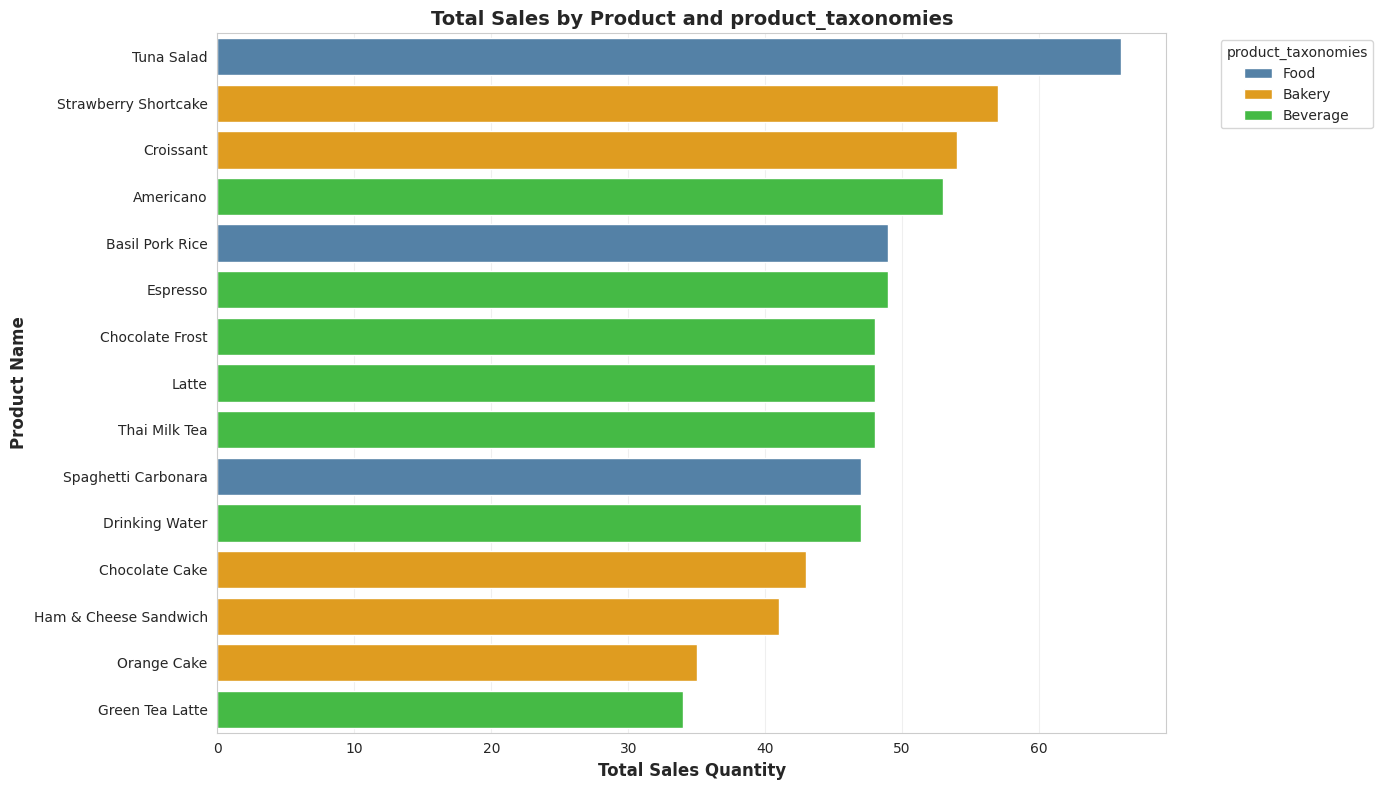

In [87]:
product_taxonomies_colors = {
    'Beverage': 'limegreen',
    'Food': 'steelblue',
    'Bakery': 'orange'
}

plot_data = sale_data.groupby(['product_name', 'product_taxonomies'])['qty'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='qty', y='product_name', hue='product_taxonomies', data=plot_data, palette=product_taxonomies_colors)
plt.xlabel('Total Sales Quantity', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')
plt.title('Total Sales by Product and product_taxonomies', fontsize=14, fontweight='bold')
plt.legend(title='product_taxonomies', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

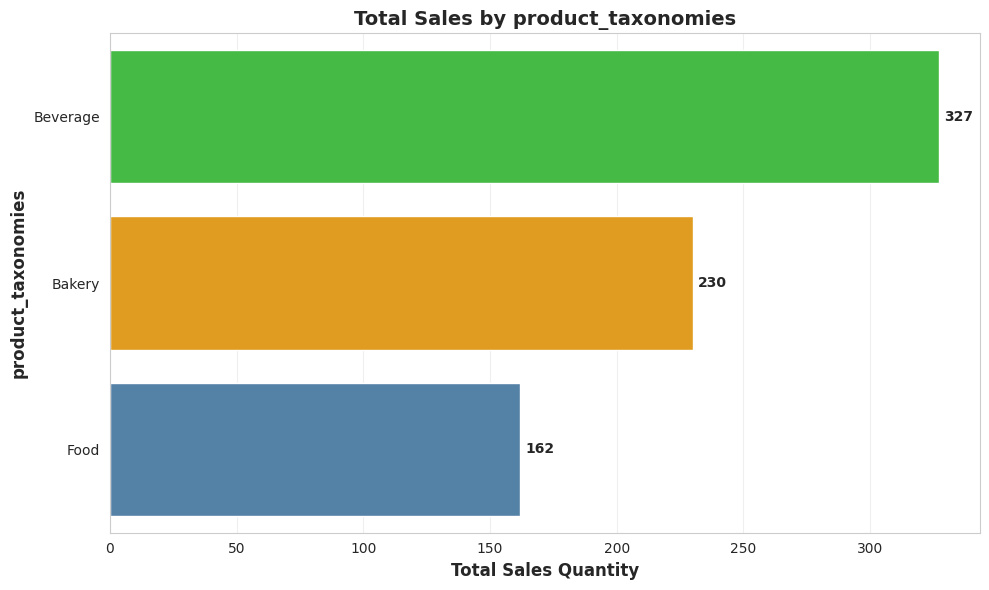

In [88]:
product_taxonomies_data = sale_data.groupby('product_taxonomies')['qty'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='qty', y='product_taxonomies', data=product_taxonomies_data, hue='product_taxonomies', palette=product_taxonomies_colors, legend=False)
plt.xlabel('Total Sales Quantity', fontsize=12, fontweight='bold')
plt.ylabel('product_taxonomies', fontsize=12, fontweight='bold')
plt.title('Total Sales by product_taxonomies', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(product_taxonomies_data['qty']):
    plt.text(v + 2, i, str(int(v)), va='center', fontweight='bold')
    
plt.tight_layout()

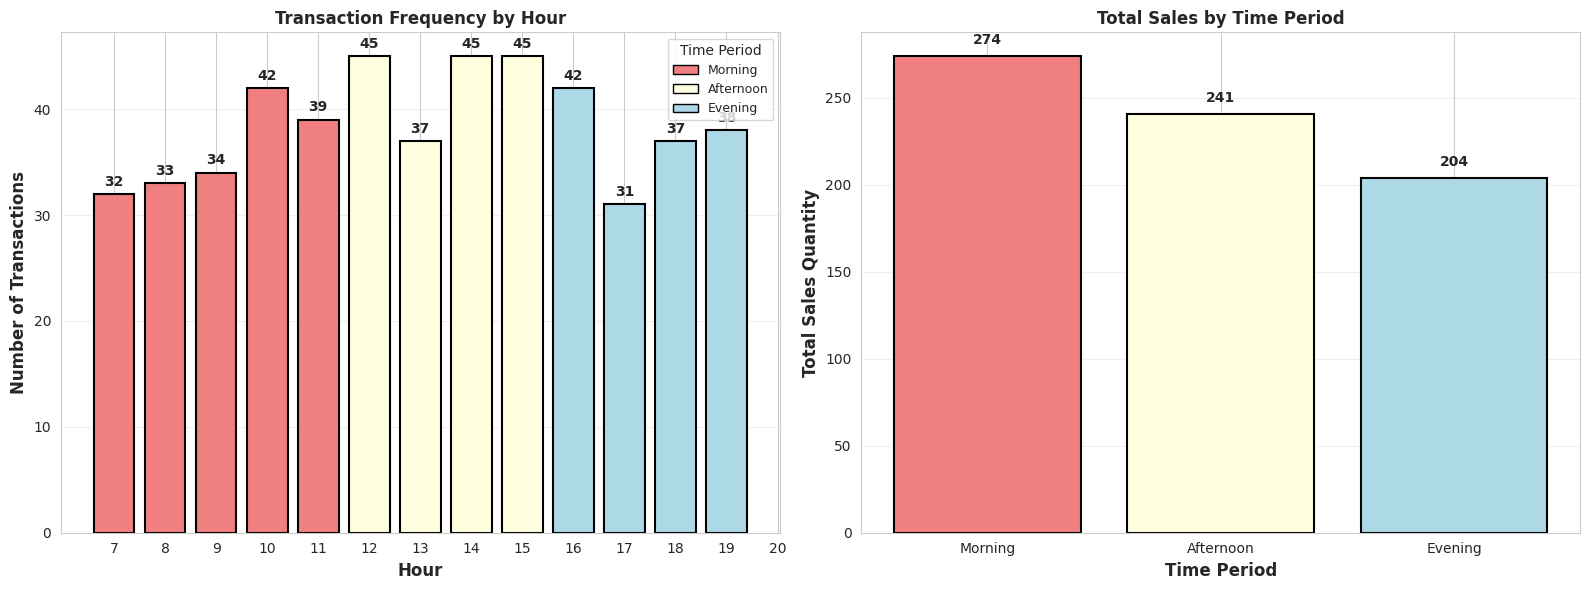

In [89]:
time_period_colors = {
    'Morning': 'lightcoral',
    'Afternoon': 'lightyellow',
    'Evening': 'lightblue'
}

time_period_order = ['Morning', 'Afternoon', 'Evening']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT SUBPLOT: Transaction Frequency by Hour
transaction_by_hour = sale_data.groupby('hour').size().reset_index(name='transaction_count')
transaction_by_hour['time_period'] = transaction_by_hour['hour'].apply(get_time_period)

colors_list = [time_period_colors[transaction_by_hour.loc[idx, 'time_period']] for idx in range(len(transaction_by_hour))]
axes[0].bar(transaction_by_hour['hour'], transaction_by_hour['transaction_count'], color=colors_list, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Hour', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Transactions', fontsize=12, fontweight='bold')
axes[0].set_title('Transaction Frequency by Hour', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(7, 21))
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on left subplot
for hour, count in zip(transaction_by_hour['hour'], transaction_by_hour['transaction_count']):
    axes[0].text(hour, count + 0.5, str(int(count)), ha='center', va='bottom', fontweight='bold')

# Add legend for time periods
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=time_period_colors[period], edgecolor='black', label=period) for period in time_period_order]
axes[0].legend(handles=legend_elements, title='Time Period', loc='upper right', fontsize=9)

# RIGHT SUBPLOT: Sales Quantity by Time Period
time_period_data = sale_data.groupby('time_period')['qty'].sum().reindex(time_period_order)
colors = [time_period_colors.get(period, 'gray') for period in time_period_order]

axes[1].bar(time_period_data.index, time_period_data.values, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Time Period', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Sales Quantity', fontsize=12, fontweight='bold')
axes[1].set_title('Total Sales by Time Period', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on right subplot
for period, value in zip(time_period_data.index, time_period_data.values):
    axes[1].text(period, value + 5, str(int(value)), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()

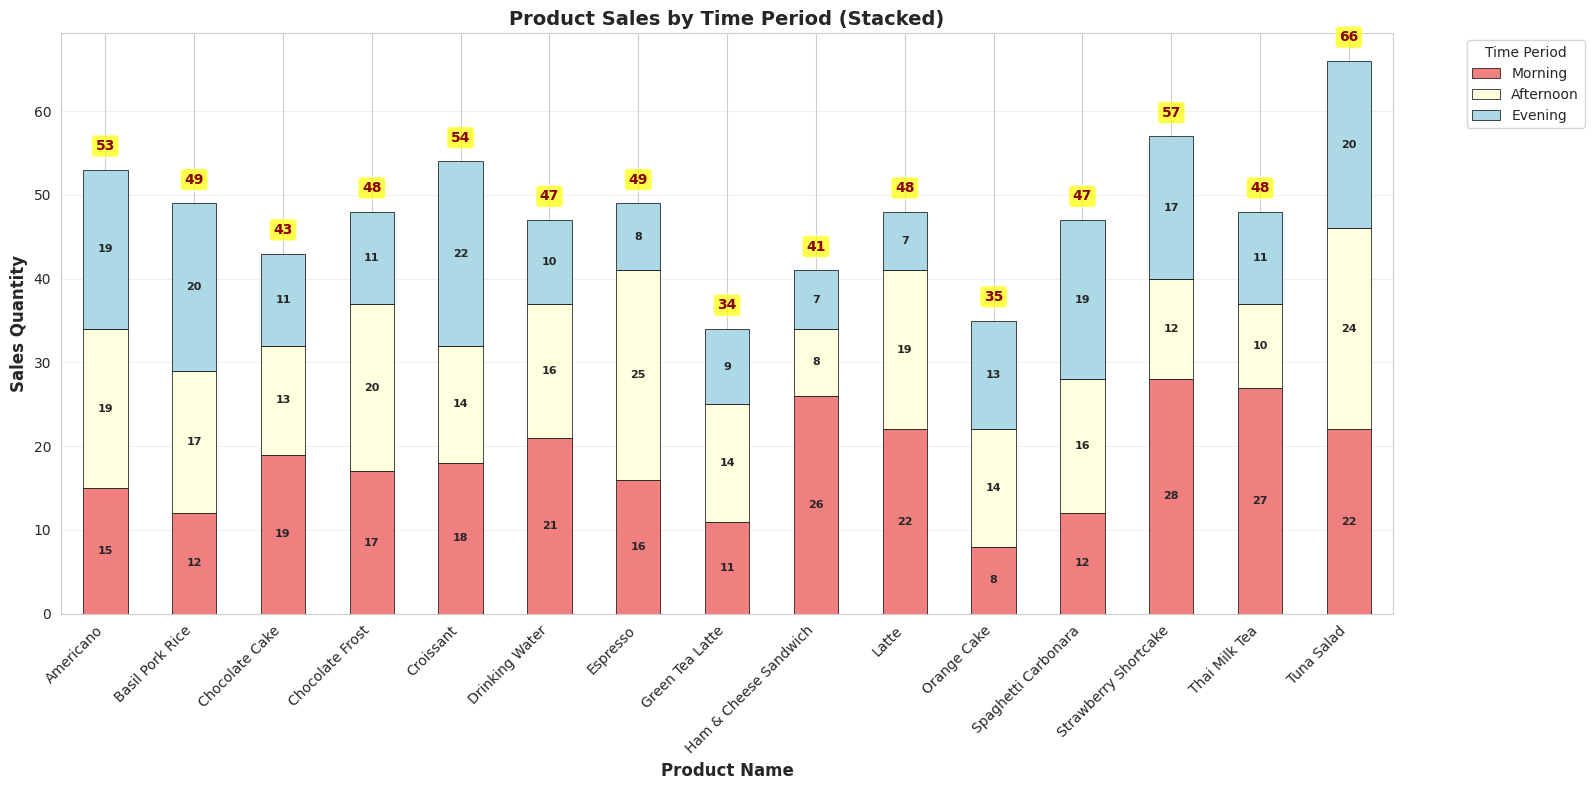

In [90]:
# Prepare data for stacked bar chart
pivot_data = sale_data.groupby(['product_name', 'time_period'])['qty'].sum().unstack(fill_value=0)
pivot_data = pivot_data[time_period_order]

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(16, 8))

pivot_data.plot(kind='bar', stacked=True, ax=ax,
                color=[time_period_colors[period] for period in time_period_order],
                edgecolor='black', linewidth=0.5)

ax.set_xlabel('Product Name', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales Quantity', fontsize=12, fontweight='bold')
ax.set_title('Product Sales by Time Period (Stacked)', fontsize=14, fontweight='bold')
ax.legend(title='Time Period', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Add numbers on segments
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontweight='bold', fontsize=8)

# Add totals on top
totals = pivot_data.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, total + 2, str(int(total)), ha='center', va='bottom',
            fontweight='bold', fontsize=10, color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

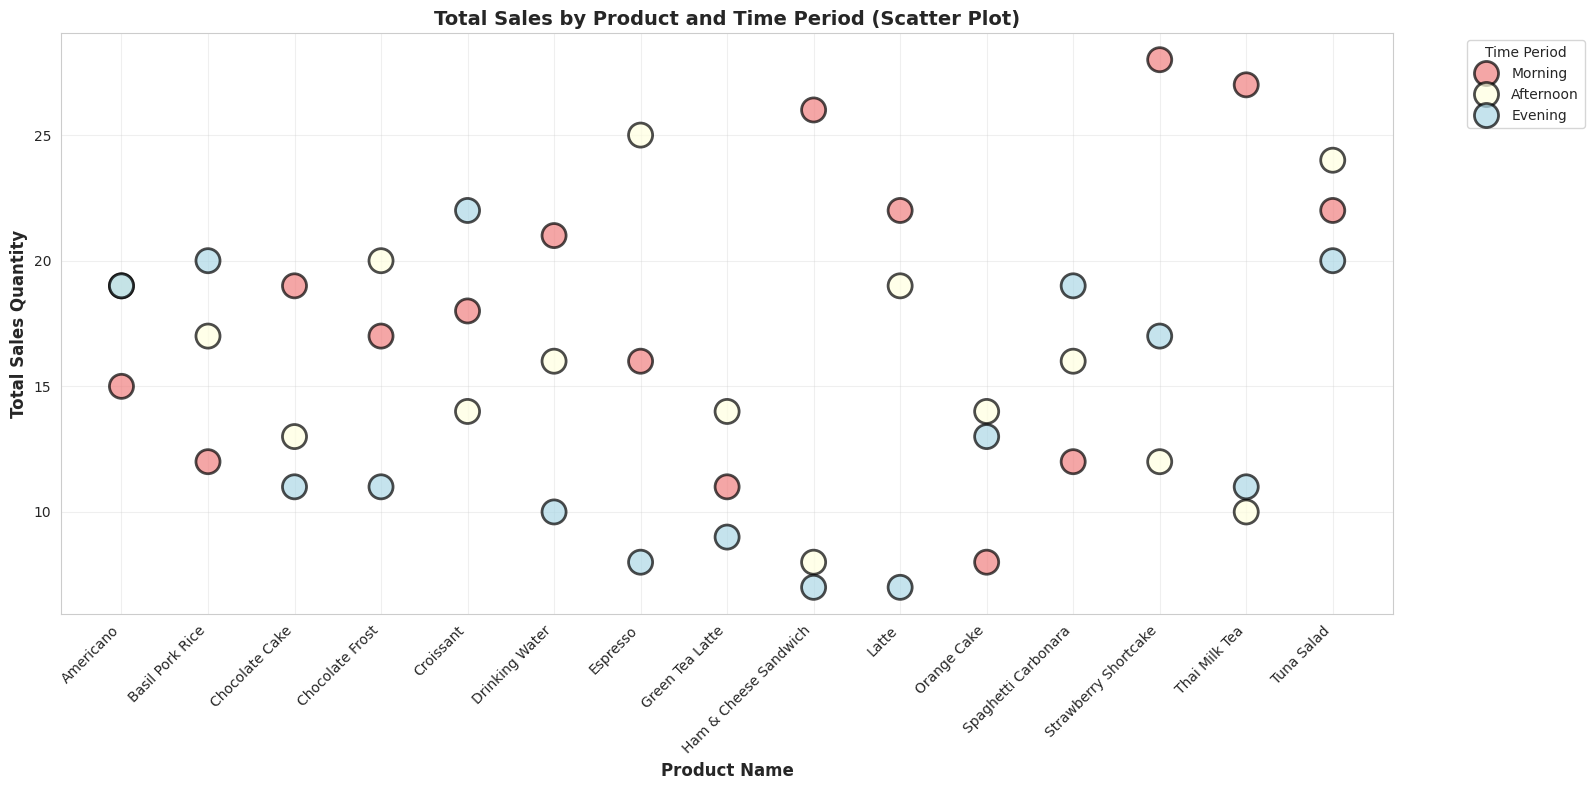

In [91]:
# Prepare data for scatter plot
scatter_data = sale_data.groupby(['product_name', 'time_period'])['qty'].sum().reset_index()

# Create scatter plot
plt.figure(figsize=(16, 8))
sns.scatterplot(
    data=scatter_data,
    x='product_name',
    y='qty',
    hue='time_period',
    hue_order=time_period_order,
    palette=time_period_colors,
    s=300,
    alpha=0.7,
    edgecolor='black',
    linewidth=2
)

plt.xlabel('Product Name', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales Quantity', fontsize=12, fontweight='bold')
plt.title('Total Sales by Product and Time Period (Scatter Plot)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Time Period', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

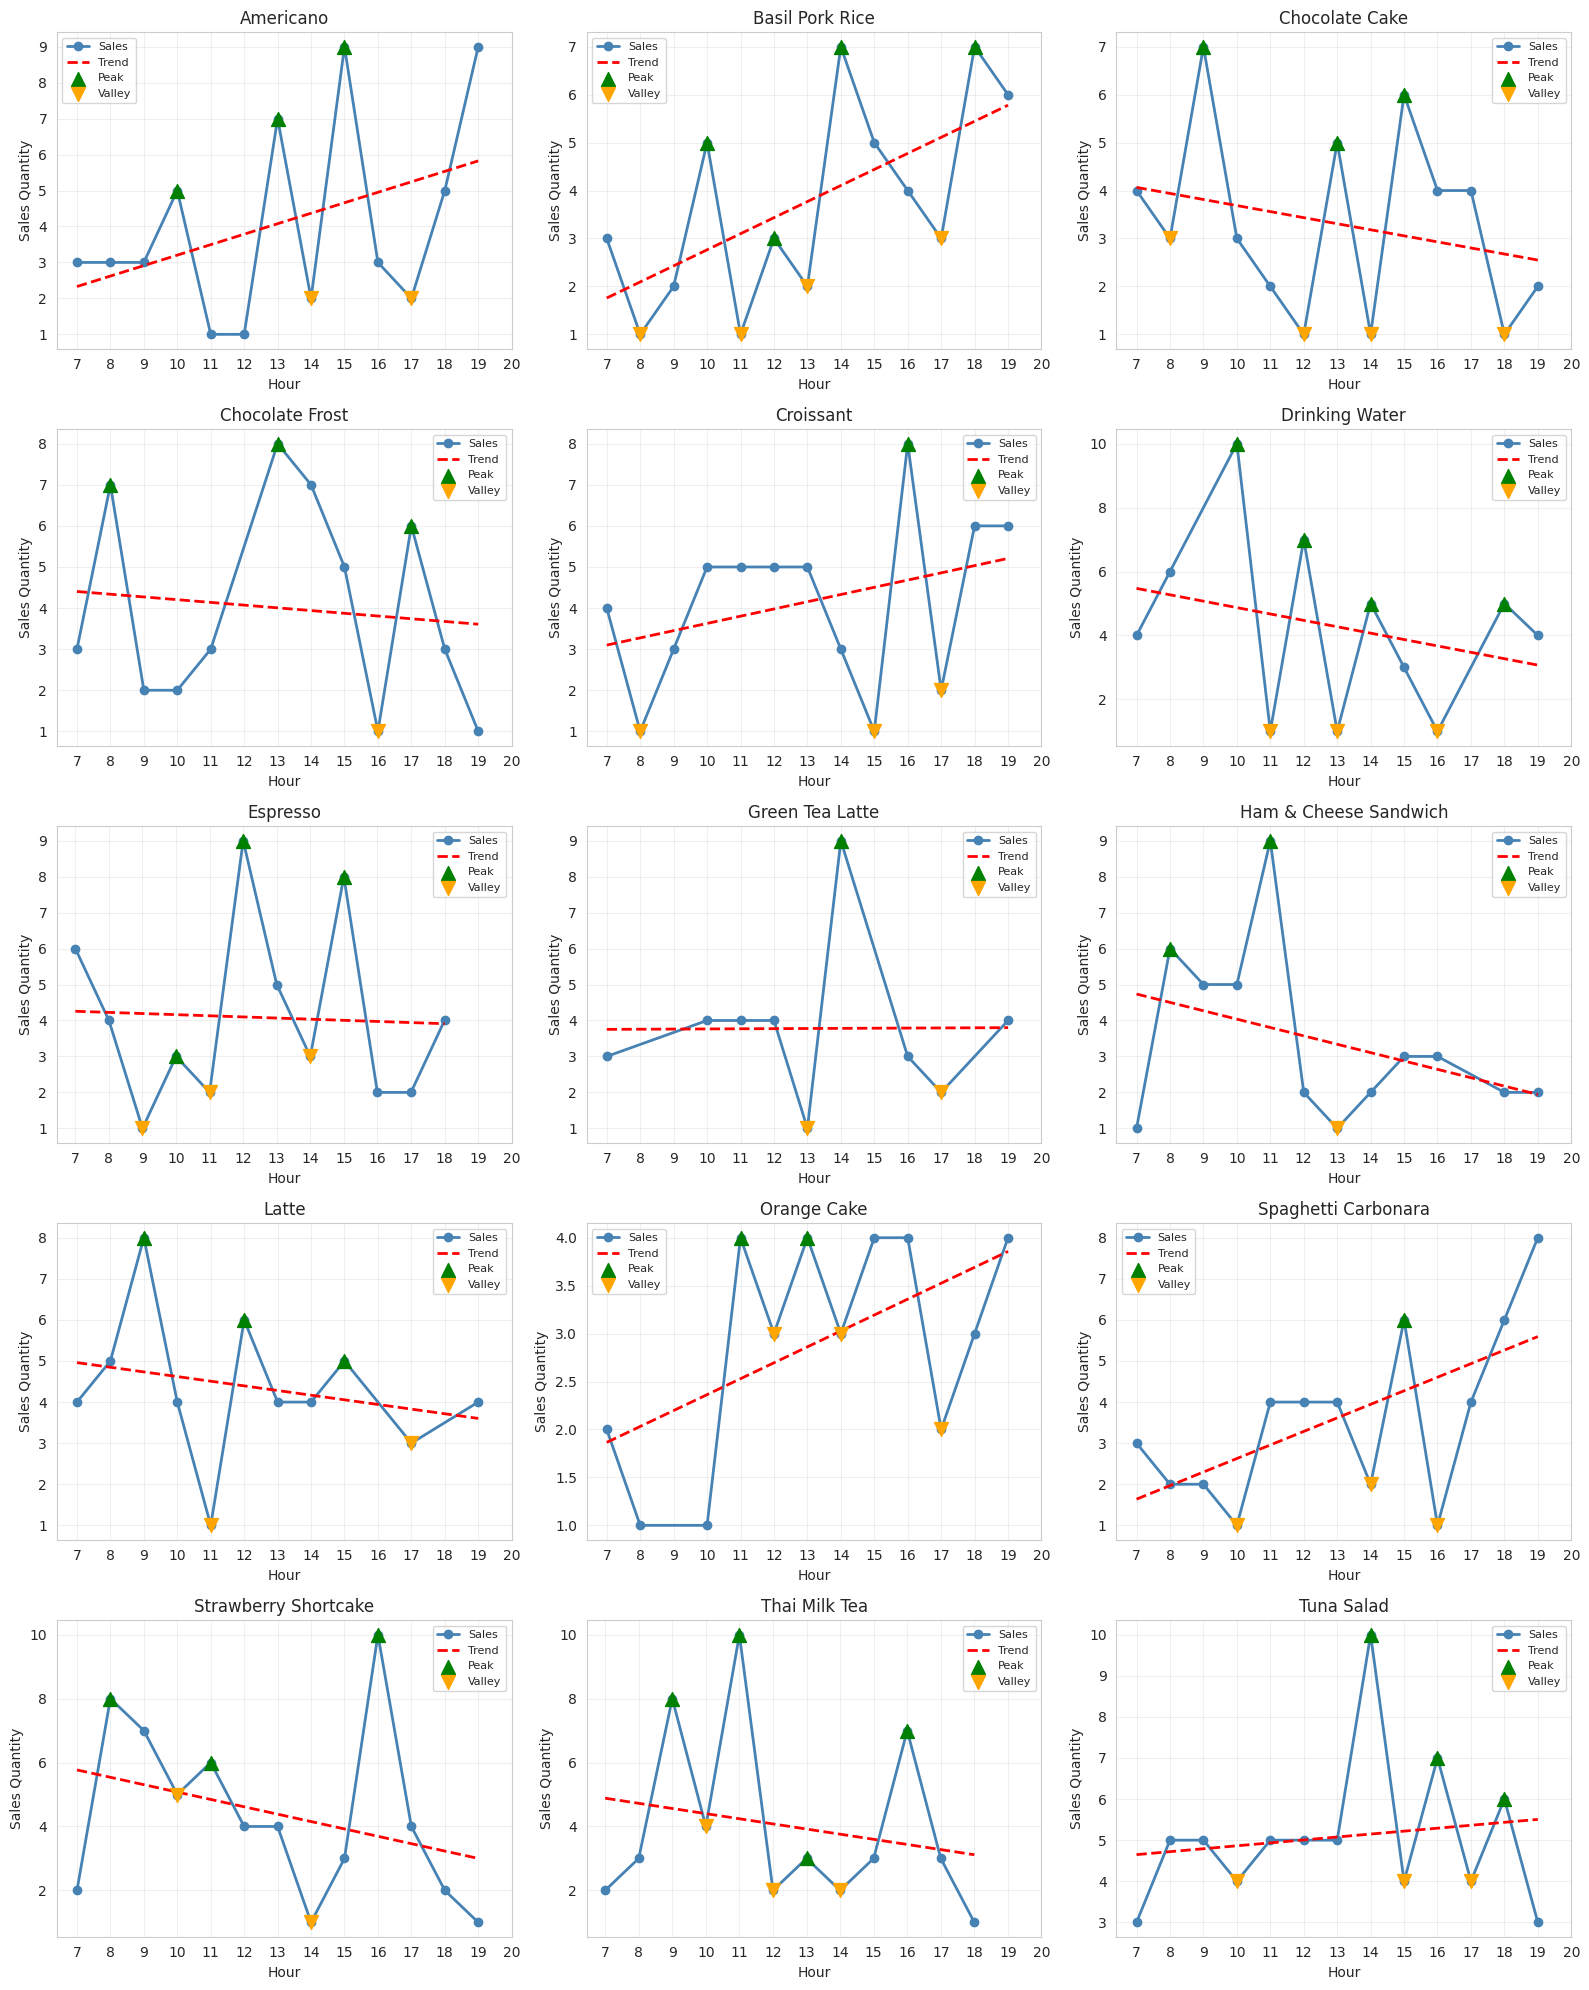

In [92]:
# Get unique products
products = sorted(hourly_sales['product_name'].unique())
num_products = len(products)
cols = 3
rows = (num_products + cols - 1) // cols

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

for idx, product in enumerate(products):
    product_data = hourly_sales[hourly_sales['product_name'] == product].sort_values('hour')
    hours = product_data['hour'].values
    quantities = product_data['qty'].values
    
    # Plot actual sales
    axes[idx].plot(hours, quantities, marker='o', linewidth=2, markersize=6, color='steelblue', label='Sales')
    
    # Add trend line
    z = np.polyfit(hours, quantities, 1)
    p = np.poly1d(z)
    trend_line = p(hours)
    axes[idx].plot(hours, trend_line, linestyle='--', linewidth=2, color='red', label='Trend')
    
    # Find changepoints
    local_max = argrelextrema(quantities, np.greater, order=1)[0]
    local_min = argrelextrema(quantities, np.less, order=1)[0]
    
    if len(local_max) > 0:
        axes[idx].scatter(hours[local_max], quantities[local_max], color='green', s=100, marker='^', label='Peak', zorder=5)
    if len(local_min) > 0:
        axes[idx].scatter(hours[local_min], quantities[local_min], color='orange', s=100, marker='v', label='Valley', zorder=5)
    
    axes[idx].set_xlabel('Hour')
    axes[idx].set_ylabel('Sales Quantity')
    axes[idx].set_title(f'{product}')
    axes[idx].set_xticks(range(7, 21))
    axes[idx].legend(loc='best', fontsize=8)
    axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(num_products, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()

## หายอดขายรายวัน